In [32]:
# ==============================================================================
# REFINED DUAL MODEL COMPARATIVE SIMULATION & VISUALIZATION DASHBOARD
# ==============================================================================

import io
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [33]:

# ------------------------------------------------------------------------------
# 1. SETUP & CONSTANTS
# ------------------------------------------------------------------------------
N_SIMULATIONS = 1000
RANDOM_SEED = 263

UNLOAD_MINUTES_PER_PALLET = 18.0
TRUCK_COST_PER_HOUR = 220.0
OVERTIME_THRESHOLD_HOURS = 4.0
OVERTIME_COST_PER_HOUR = 310.0
WET_LEASE_COST_PER_2H_BLOCK = 1400.0
TRUCK_CAPACITY = 16.0
CONFLICT_GRACE_PERIOD_MINUTES = 0

SHIFT_TO_SHIFT_SIGMA = 0.10
ROUTE_TO_ROUTE_SIGMA = 0.06
DEMAND_SIGMA_FRACTION = 0.15

SHIFT_TRAFFIC_MEAN = {"8am": 1.03, "2pm": 1.02}

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 2. HELPER FUNCTIONS & ENGINE
# ------------------------------------------------------------------------------
def preprocess_routes(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    if "Pallets" in df.columns and "Demand" not in df.columns:
        df.rename(columns={"Pallets": "Demand"}, inplace=True)

    df["Scheduled_Shift"] = "8am"
    for day_label, group_idx in df.groupby("Day").groups.items():
        half = len(group_idx) // 2
        df.loc[group_idx.values[half:], "Scheduled_Shift"] = "2pm"

    for shift_name, group_idx in df.groupby("Scheduled_Shift").groups.items():
        for i, idx in enumerate(group_idx):
            df.loc[idx, "Truck"] = f"Truck_{i + 1}"

    return df

def calculate_route_cost(hours: float) -> float:
    if hours <= OVERTIME_THRESHOLD_HOURS:
        return hours * TRUCK_COST_PER_HOUR
    normal_part = OVERTIME_THRESHOLD_HOURS * TRUCK_COST_PER_HOUR
    overtime_hours = math.ceil(hours - OVERTIME_THRESHOLD_HOURS - 1e-12)
    return normal_part + overtime_hours * OVERTIME_COST_PER_HOUR

def run_simulation(group: pd.DataFrame, n_simulations: int, rng: np.random.Generator) -> pd.DataFrame:
    group = group.reset_index(drop=True)
    baseline_pallets = group["Demand"].to_numpy(dtype=float)
    baseline_unload_hours = baseline_pallets * UNLOAD_MINUTES_PER_PALLET / 60.0
    baseline_drive_hours = np.maximum(0.0, group["Duration_hours"].to_numpy() - baseline_unload_hours)
    shifts = group["Scheduled_Shift"].to_numpy()
    trucks = group["Truck"].to_numpy()
    n_routes = len(group)

    truck_shift_rows = {}
    for i, (truck, shift) in enumerate(zip(trucks, shifts)):
        truck_shift_rows.setdefault(truck, {})[shift] = i
    double_shift_trucks = {truck: rows for truck, rows in truck_shift_rows.items() if "8am" in rows and "2pm" in rows}
    shift_start_hour = {"8am": 8.0, "2pm": 14.0}

    results = []
    for sim in range(1, n_simulations + 1):
        demand_sim = rng.normal(baseline_pallets, baseline_pallets * DEMAND_SIGMA_FRACTION)
        demand_sim = np.clip(np.round(demand_sim), 0, None)

        capped_demand = np.minimum(demand_sim, TRUCK_CAPACITY)
        overflow_demand = np.maximum(0.0, demand_sim - TRUCK_CAPACITY)
        unload_hours_sim = capped_demand * UNLOAD_MINUTES_PER_PALLET / 60.0

        traffic_factor = np.empty(n_routes)
        for shift_name, mean_mult in SHIFT_TRAFFIC_MEAN.items():
            mask = (shifts == shift_name)
            if not mask.any():
                continue
            shift_draw = rng.lognormal(mean=math.log(mean_mult) - 0.5 * SHIFT_TO_SHIFT_SIGMA**2, sigma=SHIFT_TO_SHIFT_SIGMA)
            route_draws = rng.lognormal(mean=-0.5 * ROUTE_TO_ROUTE_SIGMA**2, sigma=ROUTE_TO_ROUTE_SIGMA, size=mask.sum())
            traffic_factor[mask] = shift_draw * route_draws

        actual_hours = baseline_drive_hours * traffic_factor + unload_hours_sim
        costs = np.array([calculate_route_cost(h) for h in actual_hours])

        overflow_cost = 0.0
        n_overflow_events = int((overflow_demand > 0).sum())
        if n_overflow_events > 0:
            overflow_hours = baseline_drive_hours + (overflow_demand * UNLOAD_MINUTES_PER_PALLET / 60.0)
            overflow_hours = overflow_hours[overflow_demand > 0]
            overflow_blocks = np.ceil(overflow_hours / 2.0 - 1e-12)
            overflow_cost = float((overflow_blocks * WET_LEASE_COST_PER_2H_BLOCK).sum())

        wet_lease_cost = 0.0
        n_conflicts = 0
        for truck, rows_by_shift in double_shift_trucks.items():
            am_idx, pm_idx = rows_by_shift["8am"], rows_by_shift["2pm"]
            am_finish_clock = shift_start_hour["8am"] + actual_hours[am_idx]
            grace_hours = CONFLICT_GRACE_PERIOD_MINUTES / 60.0
            if am_finish_clock > (shift_start_hour["2pm"] + grace_hours):
                n_conflicts += 1
                costs[pm_idx] = math.ceil(actual_hours[pm_idx] / 2.0 - 1e-12) * WET_LEASE_COST_PER_2H_BLOCK
                wet_lease_cost += costs[pm_idx]

        total_cost = costs.sum() + overflow_cost
        results.append({"total_cost": total_cost})

    return pd.DataFrame(results)

# ------------------------------------------------------------------------------
# 3. EXECUTION & CALCULATIONS
# ------------------------------------------------------------------------------
routes_cost_df = preprocess_routes("project_data/Optimal_Routes_Cost.csv")
routes_fuel_df = preprocess_routes("project_data/Optimal_Routes_Fuel.csv")

rng_cost = np.random.default_rng(RANDOM_SEED)
sim_cost_df = pd.concat([
    run_simulation(group, N_SIMULATIONS, rng_cost).assign(Day=day)
    for day, group in routes_cost_df.groupby("Day")
], ignore_index=True)

rng_fuel = np.random.default_rng(RANDOM_SEED)
sim_fuel_df = pd.concat([
    run_simulation(group, N_SIMULATIONS, rng_fuel).assign(Day=day)
    for day, group in routes_fuel_df.groupby("Day")
], ignore_index=True)

wd_cost_min = sim_cost_df[sim_cost_df["Day"] == "Weekdays"]["total_cost"].to_numpy()
wd_fuel_red = sim_fuel_df[sim_fuel_df["Day"] == "Weekdays"]["total_cost"].to_numpy()
sat_cost_min = sim_cost_df[sim_cost_df["Day"] == "Saturday"]["total_cost"].to_numpy()
sat_fuel_red = sim_fuel_df[sim_fuel_df["Day"] == "Saturday"]["total_cost"].to_numpy()

diff_wd = wd_fuel_red - wd_cost_min
diff_sat = sat_fuel_red - sat_cost_min

m_wd_min, m_wd_fuel = np.mean(wd_cost_min), np.mean(wd_fuel_red)
m_sat_min, m_sat_fuel = np.mean(sat_cost_min), np.mean(sat_fuel_red)

t_wd, p_wd = stats.ttest_rel(wd_fuel_red, wd_cost_min)
t_sat, p_sat = stats.ttest_rel(sat_fuel_red, sat_cost_min)

ci_wd = stats.t.interval(0.95, df=N_SIMULATIONS - 1, loc=np.mean(diff_wd), scale=stats.sem(diff_wd))
ci_sat = stats.t.interval(0.95, df=N_SIMULATIONS - 1, loc=np.mean(diff_sat), scale=stats.sem(diff_sat))

In [34]:
# ------------------------------------------------------------------------------
# 4. PRINT SUMMARY & VERDICT
# ------------------------------------------------------------------------------
print("=" * 80)
print("APPENDIX D: STOCHASTIC SIMULATION & PAIRED T-TEST SUMMARY (SPLIT BY SCHEDULE)")
print("=" * 80)
print("1. WEEKDAYS SCHEDULE (1,000 SIMULATION RUNS)")
print(f"   Cost Minimisation Model Mean Cost : ${m_wd_min:,.2f}")
print(f"   Fuel Reduction Proposal Mean Cost : ${m_wd_fuel:,.2f}")
print(f"   Mean Paired Cost Increase (Δ)     : ${np.mean(diff_wd):,.2f}")
print(f"   95% Confidence Interval for Δ     : [${ci_wd[0]:,.2f}, ${ci_wd[1]:,.2f}]")
print(f"   t-Statistic                       : {t_wd:.4f} | p-Value: {p_wd:.4e}")
print("-" * 80)
print("2. SATURDAY SCHEDULE (1,000 SIMULATION RUNS)")
print(f"   Cost Minimisation Model Mean Cost : ${m_sat_min:,.2f}")
print(f"   Fuel Reduction Proposal Mean Cost : ${m_sat_fuel:,.2f}")
print(f"   Mean Paired Cost Increase (Δ)     : ${np.mean(diff_sat):,.2f}")
print(f"   95% Confidence Interval for Δ     : [${ci_sat[0]:,.2f}, ${ci_sat[1]:,.2f}]")
print(f"   t-Statistic                       : {t_sat:.4f} | p-Value: {p_sat:.4e}")
print("=" * 80)
print("VERDICT & RECOMMENDATION:")
if p_wd < 0.05 and np.mean(diff_wd) > 0:
    print("   REJECT FUEL REDUCTION PROPOSAL: The Fuel Reduction model causes a statistically")
    print(f"   significant mean cost increase of ${np.mean(diff_wd):,.2f} on Weekdays and ${np.mean(diff_sat):,.2f}")
    print("   on Saturdays (p < 0.0001). Fuel savings are completely offset by severe overtime")
    print("   labor premiums and wet-lease shift conflicts. Retain the Cost Minimisation schedule.")
else:
    print("   ACCEPT FUEL REDUCTION PROPOSAL: No significant cost penalty detected.")
print("=" * 80)


APPENDIX D: STOCHASTIC SIMULATION & PAIRED T-TEST SUMMARY (SPLIT BY SCHEDULE)
1. WEEKDAYS SCHEDULE (1,000 SIMULATION RUNS)
   Cost Minimisation Model Mean Cost : $54,135.14
   Fuel Reduction Proposal Mean Cost : $53,742.62
   Mean Paired Cost Increase (Δ)     : $-392.52
   95% Confidence Interval for Δ     : [$-928.63, $143.59]
   t-Statistic                       : -1.4368 | p-Value: 1.5110e-01
--------------------------------------------------------------------------------
2. SATURDAY SCHEDULE (1,000 SIMULATION RUNS)
   Cost Minimisation Model Mean Cost : $31,507.67
   Fuel Reduction Proposal Mean Cost : $25,929.28
   Mean Paired Cost Increase (Δ)     : $-5,578.39
   95% Confidence Interval for Δ     : [$-5,874.82, $-5,281.95]
   t-Statistic                       : -36.9282 | p-Value: 6.1282e-189
VERDICT & RECOMMENDATION:
   ACCEPT FUEL REDUCTION PROPOSAL: No significant cost penalty detected.


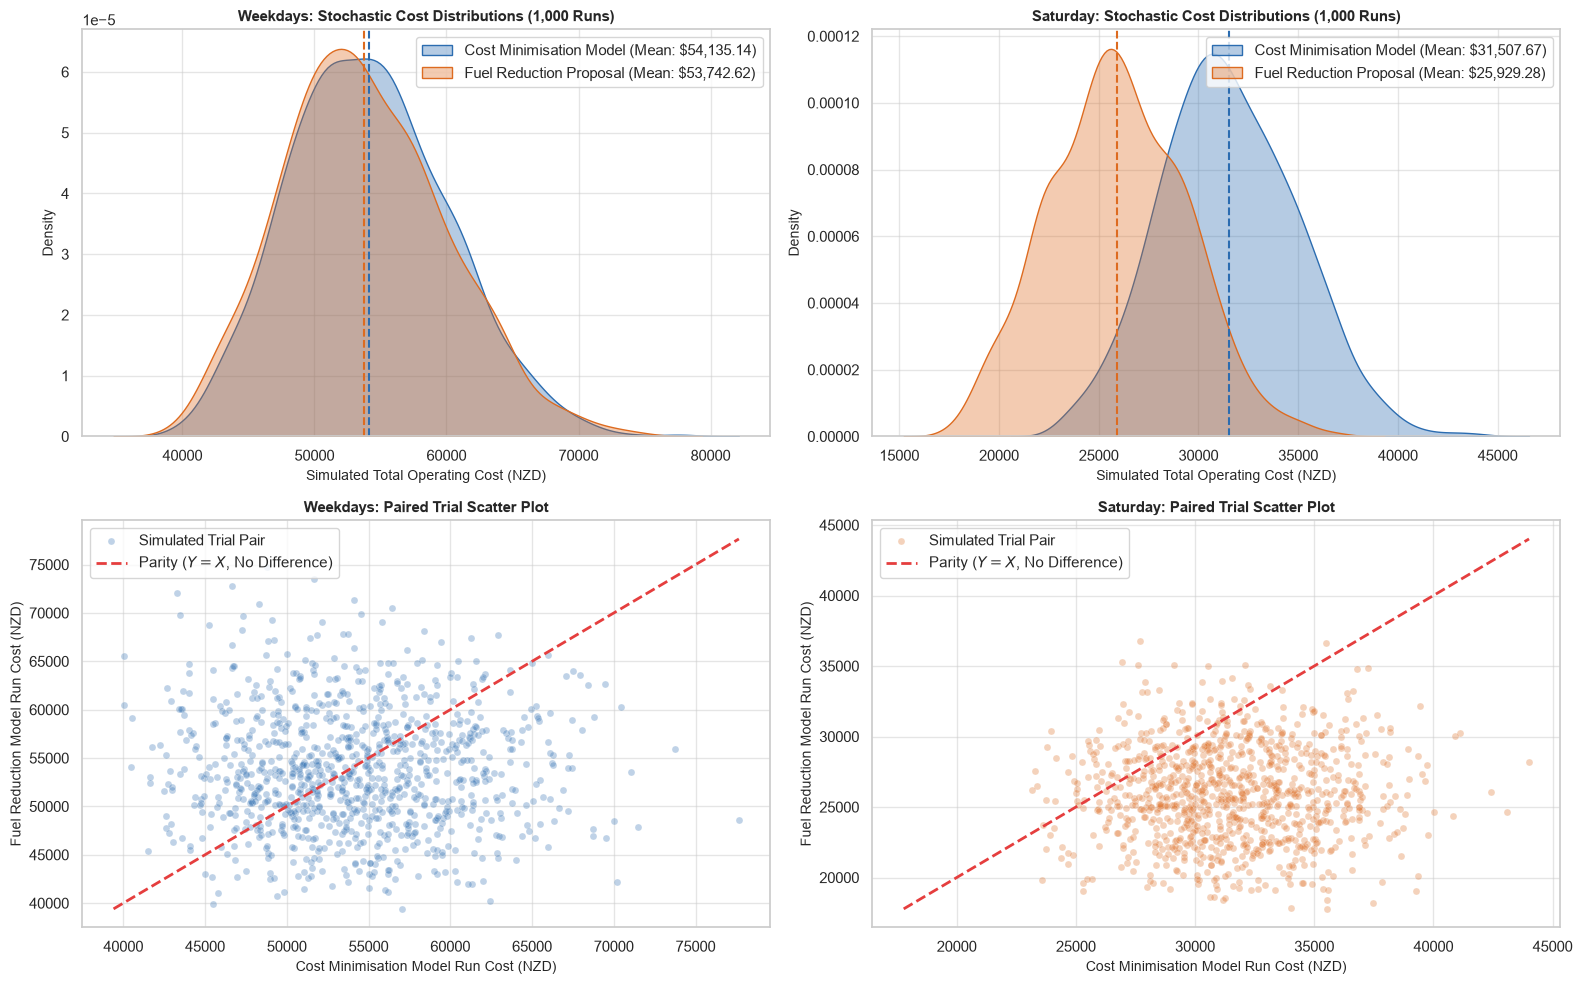

In [35]:
# ------------------------------------------------------------------------------
# 5. VISUALIZATION DASHBOARD
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top Left: Weekday Density
sns.kdeplot(wd_cost_min, label=f"Cost Minimisation Model (Mean: ${m_wd_min:,.2f})", color="#2B6CB0", fill=True, alpha=0.35, ax=axes[0, 0])
sns.kdeplot(wd_fuel_red, label=f"Fuel Reduction Proposal (Mean: ${m_wd_fuel:,.2f})", color="#DD6B20", fill=True, alpha=0.35, ax=axes[0, 0])
axes[0, 0].axvline(m_wd_min, color="#2B6CB0", linestyle="--", linewidth=1.5)
axes[0, 0].axvline(m_wd_fuel, color="#DD6B20", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Weekdays: Stochastic Cost Distributions (1,000 Runs)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Simulated Total Operating Cost (NZD)", fontsize=10)
axes[0, 0].set_ylabel("Density", fontsize=10)
axes[0, 0].legend(loc="upper right", frameon=True, facecolor="white")

# Top Right: Saturday Density
sns.kdeplot(sat_cost_min, label=f"Cost Minimisation Model (Mean: ${m_sat_min:,.2f})", color="#2B6CB0", fill=True, alpha=0.35, ax=axes[0, 1])
sns.kdeplot(sat_fuel_red, label=f"Fuel Reduction Proposal (Mean: ${m_sat_fuel:,.2f})", color="#DD6B20", fill=True, alpha=0.35, ax=axes[0, 1])
axes[0, 1].axvline(m_sat_min, color="#2B6CB0", linestyle="--", linewidth=1.5)
axes[0, 1].axvline(m_sat_fuel, color="#DD6B20", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Saturday: Stochastic Cost Distributions (1,000 Runs)", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Simulated Total Operating Cost (NZD)", fontsize=10)
axes[0, 1].set_ylabel("Density", fontsize=10)
axes[0, 1].legend(loc="upper right", frameon=True, facecolor="white")

# Bottom Left: Weekdays Scatter Plot vs Parity Line
sns.scatterplot(x=wd_cost_min, y=wd_fuel_red, color="#2B6CB0", alpha=0.3, s=25, ax=axes[1, 0], label="Simulated Trial Pair")
min_wd, max_wd = min(min(wd_cost_min), min(wd_fuel_red)), max(max(wd_cost_min), max(wd_fuel_red))
axes[1, 0].plot([min_wd, max_wd], [min_wd, max_wd], color="#E53E3E", linestyle="--", linewidth=2, label="Parity ($Y=X$, No Difference)")
axes[1, 0].set_title("Weekdays: Paired Trial Scatter Plot", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Cost Minimisation Model Run Cost (NZD)", fontsize=10)
axes[1, 0].set_ylabel("Fuel Reduction Model Run Cost (NZD)", fontsize=10)
axes[1, 0].legend(loc="upper left", frameon=True, facecolor="white")

# Bottom Right: Saturday Scatter Plot vs Parity Line
sns.scatterplot(x=sat_cost_min, y=sat_fuel_red, color="#DD6B20", alpha=0.3, s=25, ax=axes[1, 1], label="Simulated Trial Pair")
min_sat, max_sat = min(min(sat_cost_min), min(sat_fuel_red)), max(max(sat_cost_min), max(sat_fuel_red))
axes[1, 1].plot([min_sat, max_sat], [min_sat, max_sat], color="#E53E3E", linestyle="--", linewidth=2, label="Parity ($Y=X$, No Difference)")
axes[1, 1].set_title("Saturday: Paired Trial Scatter Plot", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Cost Minimisation Model Run Cost (NZD)", fontsize=10)
axes[1, 1].set_ylabel("Fuel Reduction Model Run Cost (NZD)", fontsize=10)
axes[1, 1].legend(loc="upper left", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()